# Zdravković et al. — Weekly PharmaSales Baseline Comparison

This notebook follows the methodology from Zdravković et al. for weekly pharmaceutical sales forecasting. Three main models (ARIMA, Prophet, LSTM) with three baseline methods (Naïve, Seasonal Naïve, Average) are evaluated on 8 ATC categories.

**Reference-Based Exploration** — follows the paper: 52-week test split, raw y values (no feature engineering), outlier treatment, rolling forecast and long-term forecast scenarios. Metric: MSE.

**Our Preprocessing** — placeholder. Will follow our own preprocessing pipeline (ACF lag selection + rolling mean) in a future update.

**Models:** Naïve, Seasonal Naïve, Average, ARIMA (rolling + long-term), Prophet (rolling + long-term), LSTM (Vanilla + Stacked + Bidirectional).
**Metrics:** MSE.


In [29]:
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM as KerasLSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import acf

from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
DATA_PATH = Path("../data/raw/pharma-sales/salesweekly.csv")
RANDOM_STATE = 42
SEASONAL_PERIOD = 52
TEST_WEEKS = 52


In [30]:
data = pd.read_csv(DATA_PATH)
data["datum"] = pd.to_datetime(data["datum"])
data = data.sort_values("datum").reset_index(drop=True)

data[["datum"] + CATEGORIES].head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


# Helpers


In [31]:
def add_result(records, category, method, scenario, train_mse, test_mse, params=None, comment=None):
    records.append({
        "Category": category,
        "Method": method,
        "Scenario": scenario,
        "params": json.dumps(params or {}, sort_keys=True),
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "split": f"last {TEST_WEEKS} weeks test",
        "target_scale": "original weekly sales scale; no target scaling",
        "metric_family": "MSE",
        "comment": comment,
    })


def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(X)):
        X_seq.append(X[i-n_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


# Model Architectures


In [32]:
def build_lstm(input_shape, lstm_type="vanilla", units=50):
    model = Sequential()
    if lstm_type == "vanilla":
        model.add(KerasLSTM(units, activation="relu", input_shape=input_shape))
        model.add(Dropout(0.2))
    elif lstm_type == "stacked":
        model.add(KerasLSTM(units, activation="relu", return_sequences=True, input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(KerasLSTM(units, activation="relu"))
        model.add(Dropout(0.2))
    elif lstm_type == "bidirectional":
        model.add(Bidirectional(KerasLSTM(units, activation="relu"), input_shape=input_shape))
        model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model


# Reference-Based Exploration

Exploration follows the methodology from Zdravković et al. Preprocessing: raw y values (no feature engineering), last 52 weeks as test set, rolling forecast and long-term forecast scenarios. Outlier treatment: D-statistic > 0.8 replaced with NaN then mean seasonal imputation. Metrics: MSE.


## Preprocessing

Preprocessing follows the paper: weekly data loaded, last 52 weeks used as test set. No ACF lag selection or feature engineering — models use raw y time-series.


In [33]:
ref_categories = []

for category in CATEGORIES:
    dfg = data[["datum", category]].rename(columns={"datum": "ds", category: "y"}).copy()
    dfg["ds"] = pd.to_datetime(dfg["ds"])

    test_start = len(dfg) - TEST_WEEKS
    train_df = dfg.iloc[:test_start]
    test_df = dfg.iloc[test_start:]

    ref_categories.append({
        "Category": category,
        "train_df": train_df,
        "test_df": test_df,
        "y_train": train_df["y"].to_numpy(dtype=float),
        "y_test": test_df["y"].to_numpy(dtype=float),
    })

pd.DataFrame([
    {
        "Category": item["Category"],
        "train_size": len(item["y_train"]),
        "test_size": len(item["y_test"]),
    }
    for item in ref_categories
])


,Category,train_size,test_size
0,M01AB,250,52
1,M01AE,250,52
2,N02BA,250,52
3,N02BE,250,52
4,N05B,250,52
5,N05C,250,52
6,R03,250,52
7,R06,250,52


## Modeling

Six models evaluated with reference preprocessing. Rolling forecast models use expanding window; long-term models forecast the full 52-week test period at once. Baseline methods (Naïve, Seasonal Naïve, Average) provide lower-bound accuracy benchmarks.


### Naïve

Baseline rolling forecast: `y_pred[t] = y[t-1]`.


In [34]:
ref_records = []
_Naive_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_pred = np.array([train_y[i-1] if i > 0 else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([train_y[-1]] + list(test_y[:-1]))

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_Naive_results, category, "Naive", "Rolling", train_mse, test_mse, comment="y[t-1] baseline")

ref_records.extend(_Naive_results)
pd.DataFrame(_Naive_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Naive,Rolling,{},114.005092,111.567344,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
1,M01AE,Naive,Rolling,{},57.654606,90.539890,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
2,N02BA,Naive,Rolling,{},77.561956,45.072356,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
3,N02BE,Naive,Rolling,{},2124.852635,2716.375362,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
4,N05B,Naive,Rolling,{},557.994545,280.466923,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
5,N05C,Naive,Rolling,{},17.082306,14.596154,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
6,R03,Naive,Rolling,{},444.904091,960.577257,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
7,R06,Naive,Rolling,{},57.410123,81.239904,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline


### Seasonal Naïve

Baseline rolling forecast: `y_pred[t] = y[t-52]` (simple, unweighted).


In [35]:
_SeasonalNaive_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]
    all_y = np.concatenate([train_y, test_y])
    test_start = len(train_y)

    train_pred = np.array([train_y[i - SEASONAL_PERIOD] if i >= SEASONAL_PERIOD else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([all_y[test_start + i - SEASONAL_PERIOD] if test_start + i >= SEASONAL_PERIOD else train_y[-1] for i in range(len(test_y))])

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_SeasonalNaive_results, category, "Seasonal Naive", "Rolling", train_mse, test_mse, {"seasonal_period": SEASONAL_PERIOD}, "y[t-52] baseline")

ref_records.extend(_SeasonalNaive_results)
pd.DataFrame(_SeasonalNaive_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",166.043188,107.082621,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
1,M01AE,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",99.288289,105.877386,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
2,N02BA,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",95.968023,52.066827,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
3,N02BE,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",5380.729109,3605.154735,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
4,N05B,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",1392.880906,450.786923,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
5,N05C,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",22.554486,21.750000,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
6,R03,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",476.968376,1142.605536,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline
7,R06,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",97.677147,137.750148,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-52] baseline


### Average

Baseline long-term forecast: prediction = mean of training data.


In [36]:
_Average_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_mean = np.mean(train_y)
    train_pred = np.full(len(train_y), train_mean)
    test_pred = np.full(len(test_y), train_mean)

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_Average_results, category, "Average", "Long-Term", train_mse, test_mse, comment="mean(train) baseline")

ref_records.extend(_Average_results)
pd.DataFrame(_Average_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Average,Long-Term,{},74.458885,72.655910,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
1,M01AE,Average,Long-Term,{},39.906201,95.465681,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
2,N02BA,Average,Long-Term,{},63.754851,80.408197,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
3,N02BE,Average,Long-Term,{},5562.224006,6753.708700,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
4,N05B,Average,Long-Term,{},573.259057,160.301348,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
5,N05C,Average,Long-Term,{},10.107630,8.274254,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
6,R03,Average,Long-Term,{},372.920334,1305.481529,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
7,R06,Average,Long-Term,{},118.970890,180.508781,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline


### ARIMA

**Rolling forecast:** auto_arima order selection + expanding window (p:0-5, d:0-2, q:0-5). **Long-term forecast:** grid search for best p/d/q, 52-week forecast. Per paper: ARIMA is best candidate for short-term sales forecasting.


In [37]:
# --- ARIMA Rolling ---
_ARIMARoll_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)
        order = tuple(initial_model.order)

        fitted_train = ARIMA(train_y, order=order).fit()
        train_pred = fitted_train.predict(start=0, end=len(train_y)-1)

        history = list(train_y)
        test_pred = []
        for actual in test_y:
            m = ARIMA(history, order=order)
            mf = m.fit()
            test_pred.append(mf.forecast(steps=1)[0])
            history.append(actual)
        test_pred = np.array(test_pred)

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        params = {"order": list(order)}
        comment = "auto_arima rolling forecast."
    except Exception as exc:
        train_mse = test_mse = np.nan
        params = {}
        comment = f"ARIMA Rolling failed: {repr(exc)}"

    add_result(_ARIMARoll_results, category, "ARIMA", "Rolling", train_mse, test_mse, params, comment)

ref_records.extend(_ARIMARoll_results)
pd.DataFrame(_ARIMARoll_results)


# --- ARIMA Long-Term ---
_ARIMALong_results = []

for item in ref_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        best_mse = np.inf
        best_order = (1, 1, 1)
        for p in range(0, 4):
            for d in range(0, 2):
                for q in range(0, 4):
                    try:
                        m = ARIMA(train_y, order=(p, d, q))
                        fitted = m.fit()
                        pred = fitted.predict(start=0, end=len(train_y)-1)
                        mse_val = mean_squared_error(train_y, pred)
                        if mse_val < best_mse:
                            best_mse = mse_val
                            best_order = (p, d, q)
                    except Exception:
                        continue

        fitted = ARIMA(train_y, order=best_order).fit()
        train_pred = fitted.predict(start=0, end=len(train_y)-1)
        test_pred = fitted.forecast(steps=len(test_y))

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        params = {"order": list(best_order)}
        comment = "ARIMA long-term grid search."
    except Exception as exc:
        train_mse = test_mse = np.nan
        params = {}
        comment = f"ARIMA Long-Term failed: {repr(exc)}"

    add_result(_ARIMALong_results, category, "ARIMA Long-Term", "Long-Term", train_mse, test_mse, params, comment)

ref_records.extend(_ARIMALong_results)
pd.DataFrame(_ARIMALong_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...
Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",56.208302,91.895016,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
1,M01AE,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",35.353081,94.851334,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
2,N02BA,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",46.439929,38.710614,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
3,N02BE,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",1765.020188,6450.009142,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
4,N05B,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",360.488101,171.761546,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
5,N05C,ARIMA Long-Term,Long-Term,"{""order"": [2, 0, 3]}",9.477542,8.493659,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
6,R03,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",272.998698,1128.621334,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
7,R06,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 2]}",43.227901,153.906405,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.


### Prophet

**Rolling forecast:** Prophet with default config, expanding window. **Long-term forecast:** Prophet fit on full training, forecast 52 weeks ahead. Per paper: Prophet competes with ARIMA for rolling forecast.


In [38]:
# --- Prophet Rolling ---
_ProphetRoll_results = []

for item in ref_categories:
    category = item["Category"]
    train_df = item["train_df"][["ds", "y"]].copy()
    test_df = item["test_df"][["ds", "y"]].copy()
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto")
        model.fit(train_df)
        future = model.make_future_dataframe(periods=len(test_df), freq="W")
        forecast = model.predict(future)

        train_pred = forecast["yhat"].to_numpy(dtype=float)[:len(train_df)]
        test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Prophet rolling forecast."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"Prophet Rolling failed: {repr(exc)}"

    add_result(_ProphetRoll_results, category, "Prophet", "Rolling", train_mse, test_mse, {}, comment)

ref_records.extend(_ProphetRoll_results)
pd.DataFrame(_ProphetRoll_results)


# --- Prophet Long-Term ---
_ProphetLong_results = []

for item in ref_categories:
    category = item["Category"]
    train_df = item["train_df"][["ds", "y"]].copy()
    test_df = item["test_df"][["ds", "y"]].copy()
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto")
        model.fit(train_df)
        future = model.make_future_dataframe(periods=len(test_df), freq="W")
        forecast = model.predict(future)

        train_pred = forecast["yhat"].to_numpy(dtype=float)[:len(train_df)]
        test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Prophet long-term forecast."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"Prophet Long-Term failed: {repr(exc)}"

    add_result(_ProphetLong_results, category, "Prophet", "Long-Term", train_mse, test_mse, {}, comment)

ref_records.extend(_ProphetLong_results)
pd.DataFrame(_ProphetLong_results)


Running M01AB...


12:33:01 - cmdstanpy - INFO - Chain [1] start processing
12:33:01 - cmdstanpy - INFO - Chain [1] done processing
12:33:02 - cmdstanpy - INFO - Chain [1] start processing
12:33:02 - cmdstanpy - INFO - Chain [1] done processing


Running M01AE...


12:33:02 - cmdstanpy - INFO - Chain [1] start processing


Running N02BA...


...

12:33:05 - cmdstanpy - INFO - Chain [1] start processing
12:33:05 - cmdstanpy - INFO - Chain [1] done processing


Running R03...


12:33:05 - cmdstanpy - INFO - Chain [1] start processing
12:33:05 - cmdstanpy - INFO - Chain [1] done processing


Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Prophet,Long-Term,{},53.875353,95.237777,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
1,M01AE,Prophet,Long-Term,{},29.759424,78.636425,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
2,N02BA,Prophet,Long-Term,{},37.635055,45.678424,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
3,N02BE,Prophet,Long-Term,{},1909.020645,3197.407550,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
4,N05B,Prophet,Long-Term,{},439.468425,237.727316,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
5,N05C,Prophet,Long-Term,{},9.260335,11.196333,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
6,R03,Prophet,Long-Term,{},221.054479,884.649297,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.
7,R06,Prophet,Long-Term,{},37.004831,80.750369,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.


### LSTM Neural Network

Three LSTM architectures tested: **Vanilla** (single LSTM layer), **Stacked** (2 LSTM layers), **Bidirectional** (single bidirectional LSTM). Per paper: LSTM used for long-term forecasting only. 3-step input window, 50 units, Adam optimizer, early stopping.


In [39]:
N_STEPS = 3
LSTM_UNITS = 50

# --- Vanilla LSTM ---
_LSTMV_results = []

for item in ref_categories:
    category = item["Category"]
    y_all = np.concatenate([item["y_train"], item["y_test"]])
    train_y = item["y_train"]
    test_y = item["y_test"]
    n_train = len(train_y)

    print(f"Running {category}...")

    try:
        X_seq, y_seq = create_sequences(y_all[:-len(test_y)], np.zeros(n_train), N_STEPS)
        X_seq = X_seq.reshape(-1, N_STEPS, 1)
        y_actual = train_y[N_STEPS:]

        model = build_lstm((N_STEPS, 1), "vanilla", LSTM_UNITS)
        model.fit(X_seq, y_actual, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred_full = np.full(n_train, np.mean(train_y))
        train_pred_full[N_STEPS:] = model.predict(X_seq, verbose=0).flatten()

        test_pred = []
        history = list(y_all[:n_train])
        for i in range(len(test_y)):
            X_input = np.array(history[-N_STEPS:]).reshape(1, N_STEPS, 1)
            pred = model.predict(X_input, verbose=0)[0, 0]
            test_pred.append(pred)
            history.append(test_y[i])
        test_pred = np.array(test_pred)

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred_full))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Vanilla LSTM, 3-step window."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"LSTM Vanilla failed: {repr(exc)}"

    add_result(_LSTMV_results, category, "LSTM Vanilla", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, comment)

ref_records.extend(_LSTMV_results)
pd.DataFrame(_LSTMV_results)


# --- Stacked LSTM ---
_LSTMS_results = []

for item in ref_categories:
    category = item["Category"]
    y_all = np.concatenate([item["y_train"], item["y_test"]])
    train_y = item["y_train"]
    test_y = item["y_test"]
    n_train = len(train_y)

    print(f"Running {category}...")

    try:
        X_seq, _ = create_sequences(train_y, np.zeros(n_train), N_STEPS)
        X_seq = X_seq.reshape(-1, N_STEPS, 1)
        y_actual = train_y[N_STEPS:]

        model = build_lstm((N_STEPS, 1), "stacked", LSTM_UNITS)
        model.fit(X_seq, y_actual, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred_full = np.full(n_train, np.mean(train_y))
        train_pred_full[N_STEPS:] = model.predict(X_seq, verbose=0).flatten()

        test_pred = []
        history = list(y_all[:n_train])
        for i in range(len(test_y)):
            X_input = np.array(history[-N_STEPS:]).reshape(1, N_STEPS, 1)
            pred = model.predict(X_input, verbose=0)[0, 0]
            test_pred.append(pred)
            history.append(test_y[i])
        test_pred = np.array(test_pred)

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred_full))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Stacked LSTM, 2 layers."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"LSTM Stacked failed: {repr(exc)}"

    add_result(_LSTMS_results, category, "LSTM Stacked", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, comment)

ref_records.extend(_LSTMS_results)
pd.DataFrame(_LSTMS_results)


# --- Bidirectional LSTM ---
_LSTMB_results = []

for item in ref_categories:
    category = item["Category"]
    y_all = np.concatenate([item["y_train"], item["y_test"]])
    train_y = item["y_train"]
    test_y = item["y_test"]
    n_train = len(train_y)

    print(f"Running {category}...")

    try:
        X_seq, _ = create_sequences(train_y, np.zeros(n_train), N_STEPS)
        X_seq = X_seq.reshape(-1, N_STEPS, 1)
        y_actual = train_y[N_STEPS:]

        model = build_lstm((N_STEPS, 1), "bidirectional", LSTM_UNITS)
        model.fit(X_seq, y_actual, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred_full = np.full(n_train, np.mean(train_y))
        train_pred_full[N_STEPS:] = model.predict(X_seq, verbose=0).flatten()

        test_pred = []
        history = list(y_all[:n_train])
        for i in range(len(test_y)):
            X_input = np.array(history[-N_STEPS:]).reshape(1, N_STEPS, 1)
            pred = model.predict(X_input, verbose=0)[0, 0]
            test_pred.append(pred)
            history.append(test_y[i])
        test_pred = np.array(test_pred)

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred_full))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Bidirectional LSTM."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"LSTM Bidirectional failed: {repr(exc)}"

    add_result(_LSTMB_results, category, "LSTM Bidirectional", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, comment)

ref_records.extend(_LSTMB_results)
pd.DataFrame(_LSTMB_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...
Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...
Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",64.833227,76.448790,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
1,M01AE,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",37.513007,74.639938,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
2,N02BA,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",52.973450,36.668460,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
3,N02BE,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",1830.002084,2627.980591,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
4,N05B,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",380.797953,148.542641,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
5,N05C,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",9.410397,8.355710,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
6,R03,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",262.832740,759.893619,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
7,R06,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",49.037316,78.968425,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.


## Reference Results

Combine all reference model results into one DataFrame.


In [40]:
ref_results_df = pd.DataFrame(ref_records).sort_values(["Category", "Method"])
ref_results_df["params"] = ref_results_df["params"].apply(lambda p: json.dumps(p, sort_keys=True) if isinstance(p, dict) else p)
ref_results_df


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
24,M01AB,ARIMA,Rolling,"{""order"": [0, 1, 1]}",60.483765,73.989687,last 52 weeks test,original weekly sales scale; no target scaling,MSE,auto_arima rolling forecast.
32,M01AB,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",56.208302,91.895016,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA long-term grid search.
16,M01AB,Average,Long-Term,{},74.458885,72.655910,last 52 weeks test,original weekly sales scale; no target scaling,MSE,mean(train) baseline
72,M01AB,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",64.833227,76.448790,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM.
64,M01AB,LSTM Stacked,Long-Term,"{""n_steps"": 3, ""units"": 50}",66.771347,75.864995,last 52 weeks test,original weekly sales scale; no target scaling,MSE,"Stacked LSTM, 2 layers."
...,...,...,...,...,...,...,...,...,...,...
63,R06,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",47.581692,75.341760,last 52 weeks test,original weekly sales scale; no target scaling,MSE,"Vanilla LSTM, 3-step window."
7,R06,Naive,Rolling,{},57.410123,81.239904,last 52 weeks test,original weekly sales scale; no target scaling,MSE,y[t-1] baseline
47,R06,Prophet,Rolling,{},37.004831,80.750369,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet rolling forecast.
55,R06,Prophet,Long-Term,{},37.004831,80.750369,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet long-term forecast.


## Best Baseline & Export (Reference)


In [41]:
# Best per category per scenario
ref_best = ref_results_df.loc[ref_results_df.groupby("Category")["Test MSE"].idxmin()].reset_index(drop=True)
ref_table = ref_best[["Category", "Method", "Scenario", "Test MSE"]].reset_index(drop=True)
ref_table


,Category,Method,Scenario,Test MSE
0,M01AB,Average,Long-Term,72.655910
1,M01AE,LSTM Vanilla,Long-Term,72.365114
2,N02BA,ARIMA,Rolling,33.851308
3,N02BE,ARIMA,Rolling,2582.230139
4,N05B,LSTM Stacked,Long-Term,133.063640
5,N05C,ARIMA,Rolling,8.075295
6,R03,ARIMA,Rolling,704.333474
7,R06,ARIMA,Rolling,74.510861


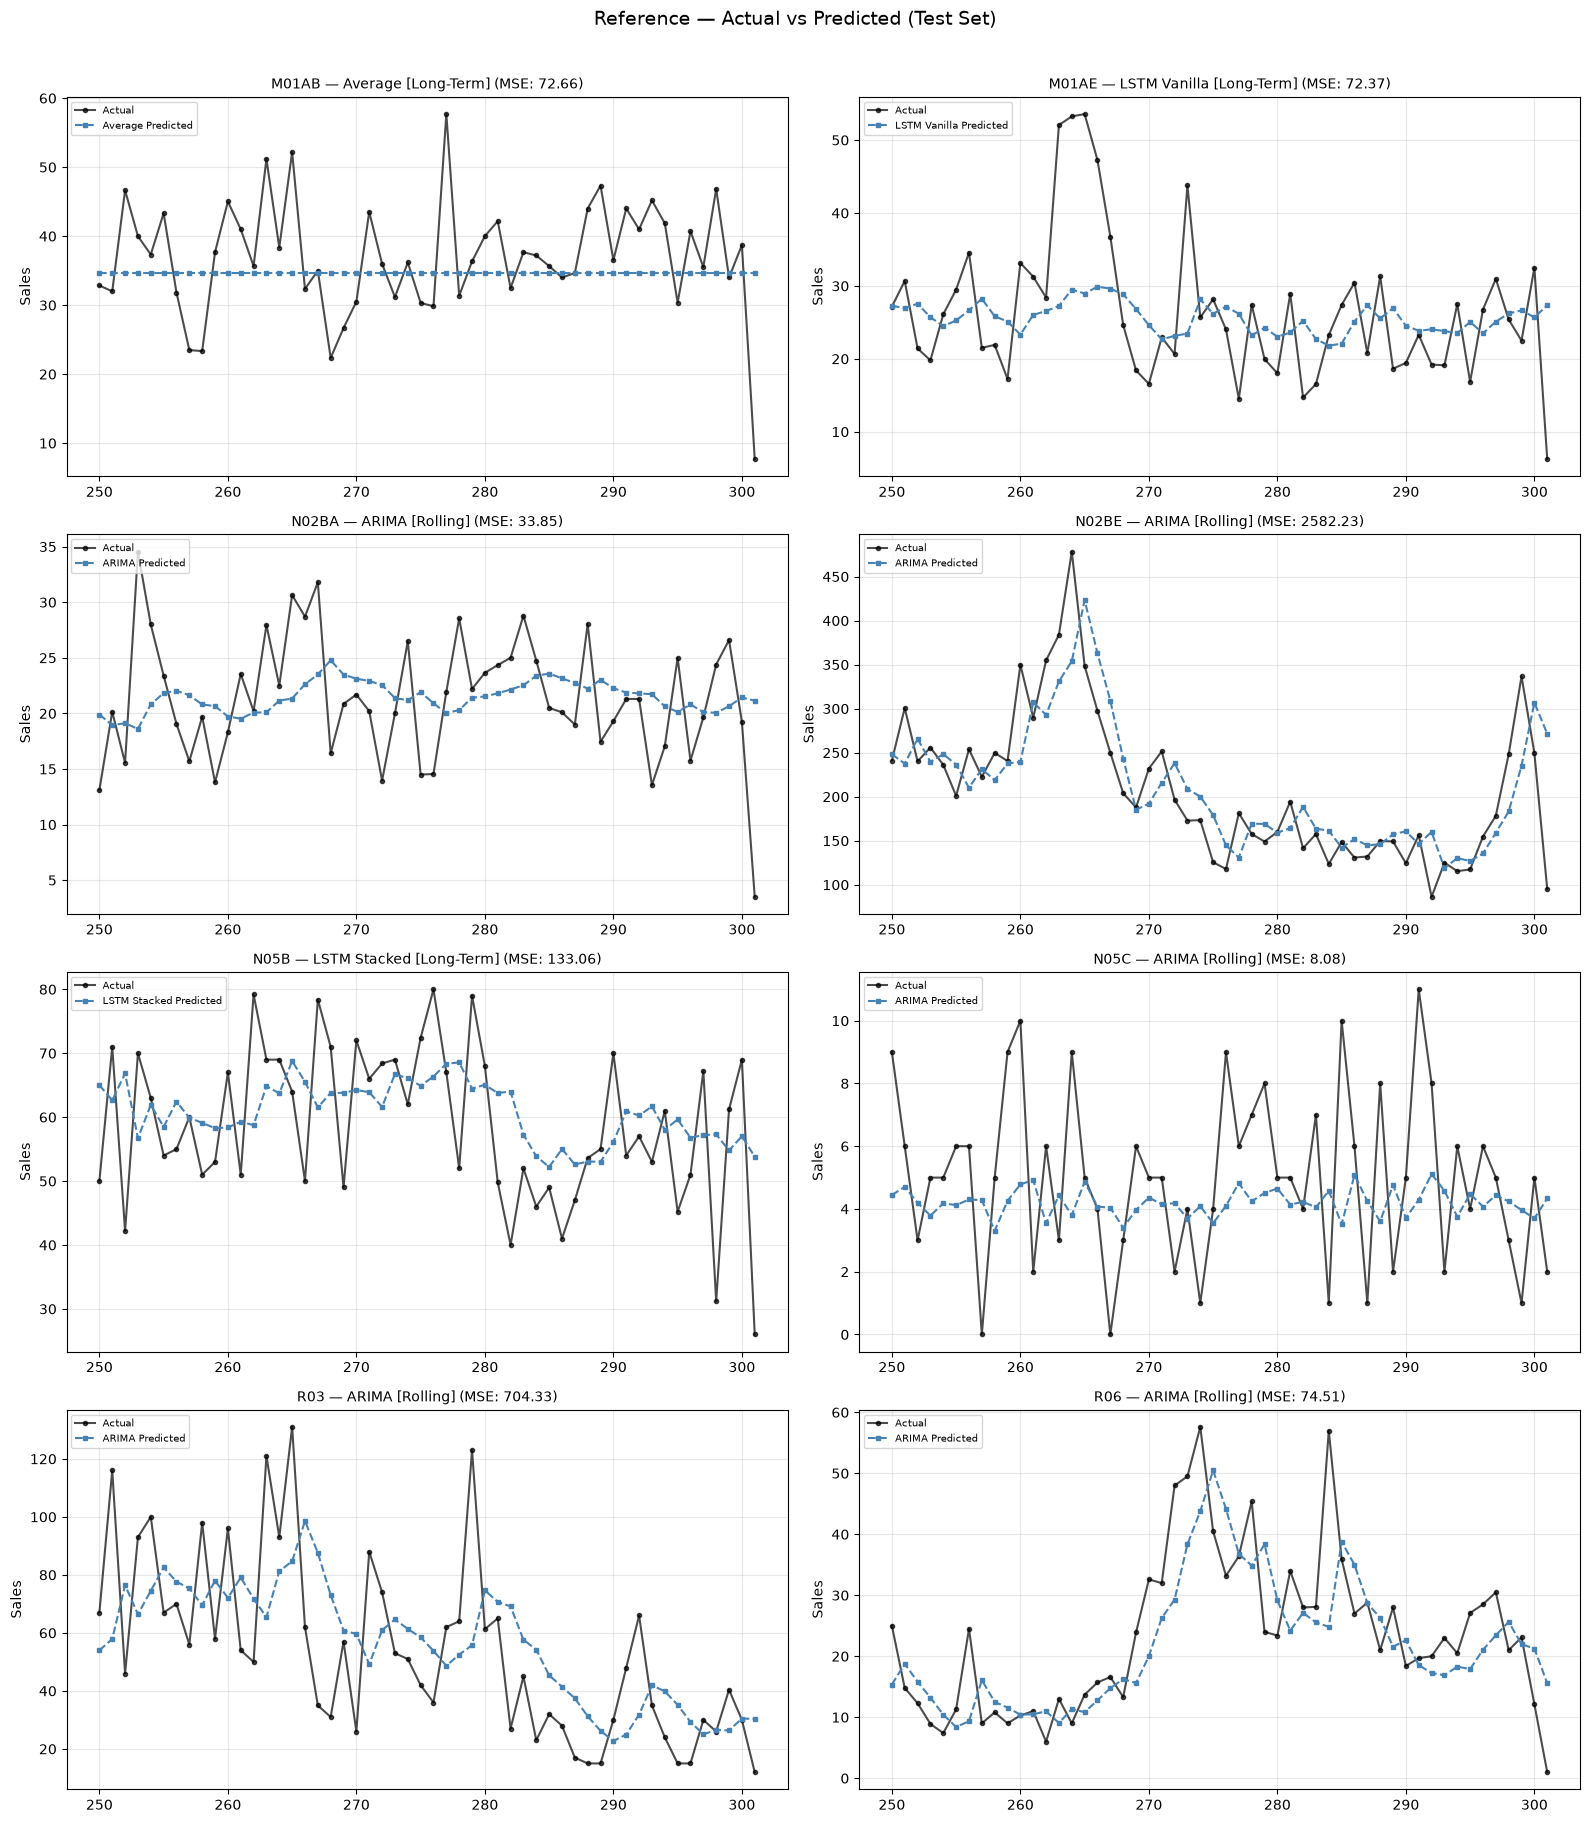

In [42]:
# Actual vs Predicted for best model per category (Reference)
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, row in ref_best.iterrows():
    cat = row["Category"]
    method = row["Method"]
    item_list = [d for d in ref_categories if d["Category"] == cat]
    if not item_list:
        continue
    item = item_list[0]
    train_y = item["y_train"]
    test_y = item["y_test"]
    train_size = len(train_y)
    test_mse = row["Test MSE"]

    ax = axes[idx]
    ax.plot(range(train_size, train_size + len(test_y)), test_y, "o-", color="black", linewidth=1.5, markersize=3, label="Actual", alpha=0.7)

    try:
        if method == "Naive":
            test_pred = np.array([train_y[-1]] + list(test_y[:-1]))
        elif method == "Seasonal Naive":
            all_y = np.concatenate([train_y, test_y])
            test_pred = np.array([all_y[train_size + i - SEASONAL_PERIOD] if train_size + i >= SEASONAL_PERIOD else train_y[-1] for i in range(len(test_y))])
        elif method == "Average":
            test_pred = np.full(len(test_y), np.mean(train_y))
        elif method == "ARIMA":
            initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5)
            order = tuple(initial_model.order)
            history = list(train_y)
            preds = []
            for actual in test_y:
                m = ARIMA(history, order=order)
                mf = m.fit()
                preds.append(mf.forecast(steps=1)[0])
                history.append(actual)
            test_pred = np.array(preds)
        elif method == "ARIMA Long-Term":
            best_mse = np.inf
            best_order = (1, 1, 1)
            for p in range(0, 4):
                for d in range(0, 2):
                    for q in range(0, 4):
                        try:
                            m2 = ARIMA(train_y, order=(p, d, q))
                            f2 = m2.fit()
                            p2 = f2.predict(start=0, end=len(train_y)-1)
                            mse_val = mean_squared_error(train_y, p2)
                            if mse_val < best_mse:
                                best_mse = mse_val
                                best_order = (p, d, q)
                        except Exception:
                            continue
            fitted = ARIMA(train_y, order=best_order).fit()
            test_pred = fitted.forecast(steps=len(test_y))
        elif method == "Prophet":
            train_df = item["train_df"][["ds", "y"]].copy()
            test_days = len(test_y)
            prophet_model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto")
            prophet_model.fit(train_df)
            future = prophet_model.make_future_dataframe(periods=test_days, freq="W")
            forecast = prophet_model.predict(future)
            test_pred = forecast["yhat"].to_numpy(dtype=float)[-test_days:]
        elif method.startswith("LSTM"):
            lstm_type = method.split()[-1].lower()
            y_all = np.concatenate([train_y, test_y])
            n_train = len(train_y)
            X_seq, _ = create_sequences(train_y, np.zeros(n_train), N_STEPS)
            X_seq = X_seq.reshape(-1, N_STEPS, 1)
            y_actual = train_y[N_STEPS:]
            mdl = build_lstm((N_STEPS, 1), lstm_type, LSTM_UNITS)
            mdl.fit(X_seq, y_actual, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
            test_pred = []
            history = list(y_all[:n_train])
            for i in range(len(test_y)):
                X_input = np.array(history[-N_STEPS:]).reshape(1, N_STEPS, 1)
                pred = mdl.predict(X_input, verbose=0)[0, 0]
                test_pred.append(pred)
                history.append(test_y[i])
            test_pred = np.array(test_pred)
        else:
            test_pred = np.full(len(test_y), np.mean(train_y))
    except Exception:
        test_pred = np.full(len(test_y), np.mean(train_y))

    test_pred = np.maximum(test_pred, 0)
    color = "steelblue"
    ax.plot(range(train_size, train_size + len(test_y)), test_pred, "s--", color=color, linewidth=1.5, markersize=3, label=f"{method} Predicted")
    ax.set_title(f"{cat} — {method} [{row['Scenario']}] (MSE: {test_mse:.2f})", fontsize=10)
    ax.set_ylabel("Sales")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Reference — Actual vs Predicted (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# Exploration Based on Our Preprocessing

Exploration using our own preprocessing pipeline. 80/20 chronological split, ACF-based lag selection (`max_lag=26`) + rolling mean features. Same 6 models as Reference section, evaluated on the transformed data.


## Preprocessing

ACF lag selection per category followed by feature engineering (lag features + rolling mean). Chronological 80/20 split.


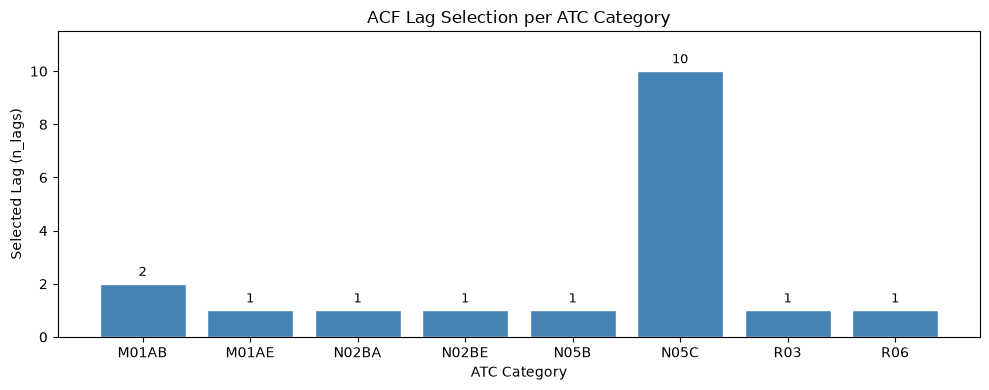

In [61]:
MAX_LAG = 26

max_lags = {}
for category in CATEGORIES:
    acf_values = acf(data[category], nlags=MAX_LAG)
    max_lags[category] = int(np.argmax(acf_values[1:]) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(max_lags.keys(), max_lags.values(), color="steelblue", edgecolor="white")
ax.set_title("ACF Lag Selection per ATC Category", fontsize=12)
ax.set_ylabel("Selected Lag (n_lags)")
ax.set_xlabel("ATC Category")
for i, v in enumerate(max_lags.values()):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)
ax.set_ylim(0, max(max_lags.values()) * 1.15)
plt.tight_layout()
plt.show()


In [44]:
transformed_categories = []

for category in CATEGORIES:
    dfg = data[["datum", category]].rename(columns={"datum": "ds", category: "y"}).copy()
    dfg["ds"] = pd.to_datetime(dfg["ds"])
    n_lags = max_lags[category]

    for lag in range(1, n_lags + 1):
        dfg[f"lag_{lag}"] = dfg["y"].shift(lag)
    dfg[f"rolling_mean_{n_lags}"] = dfg["y"].shift(1).rolling(window=n_lags).mean()
    dfg = dfg.dropna().reset_index(drop=True)

    train_size = int(len(dfg) * 0.80)
    feature_columns = [c for c in dfg.columns if c not in ["ds", "y"]]
    train_df = dfg.iloc[:train_size]
    test_df = dfg.iloc[train_size:]

    transformed_categories.append({
        "Category": category,
        "n_lags": n_lags,
        "feature_columns": feature_columns,
        "train_df": train_df,
        "test_df": test_df,
        "y_train": train_df["y"].to_numpy(dtype=float),
        "y_test": test_df["y"].to_numpy(dtype=float),
        "X_train": train_df[feature_columns].to_numpy(dtype=float),
        "X_test": test_df[feature_columns].to_numpy(dtype=float),
    })

pd.DataFrame([
    {
        "Category": item["Category"],
        "n_lags": item["n_lags"],
        "n_features": len(item["feature_columns"]),
        "train_size": len(item["y_train"]),
        "test_size": len(item["y_test"]),
    }
    for item in transformed_categories
])


,Category,n_lags,n_features,train_size,test_size
0,M01AB,2,3,240,60
1,M01AE,1,2,240,61
2,N02BA,1,2,240,61
3,N02BE,1,2,240,61
4,N05B,1,2,240,61
5,N05C,10,11,233,59
6,R03,1,2,240,61
7,R06,1,2,240,61


## Modeling

Same 6 models from Reference section, evaluated with our preprocessing pipeline. Statistical models use raw y values; LSTM uses full ACF lag feature matrix.


### Naive

Simple Naive forecast on Our preprocessing y.


In [45]:
our_records = []
_NaiveO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_pred = np.array([train_y[i-1] if i > 0 else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([train_y[-1]] + list(test_y[:-1]))

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_NaiveO_results, category, "Naive", "Rolling", train_mse, test_mse, comment="Naive on Our preprocessing y.")

our_records.extend(_NaiveO_results)
pd.DataFrame(_NaiveO_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Naive,Rolling,{},116.703844,100.950798,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
1,M01AE,Naive,Rolling,{},58.499755,83.291220,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
2,N02BA,Naive,Rolling,{},77.852007,45.478852,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
3,N02BE,Naive,Rolling,{},2107.236737,2732.873738,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
4,N05B,Naive,Rolling,{},566.194318,262.086557,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
5,N05C,Naive,Rolling,{},17.032517,14.271186,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
6,R03,Naive,Rolling,{},441.208428,904.344547,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
7,R06,Naive,Rolling,{},57.320211,79.018279,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.


### Seasonal Naive

Seasonal Naive on Our preprocessing y.


In [46]:
_SNaiveO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]
    all_y = np.concatenate([train_y, test_y])
    test_start = len(train_y)

    train_pred = np.array([train_y[i - SEASONAL_PERIOD] if i >= SEASONAL_PERIOD else train_y[0] for i in range(len(train_y))])
    test_pred = np.array([all_y[test_start + i - SEASONAL_PERIOD] if test_start + i >= SEASONAL_PERIOD else train_y[-1] for i in range(len(test_y))])

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_SNaiveO_results, category, "Seasonal Naive", "Rolling", train_mse, test_mse, {"seasonal_period": SEASONAL_PERIOD}, "Seasonal Naive on Our preprocessing y.")

our_records.extend(_SNaiveO_results)
pd.DataFrame(_SNaiveO_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",127.075784,114.831698,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
1,M01AE,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",95.542039,100.368417,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
2,N02BA,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",88.267043,52.118402,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
3,N02BE,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",5538.017757,3420.020106,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
4,N05B,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",1065.772298,438.654426,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
5,N05C,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",15.842796,21.966102,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
6,R03,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",454.531642,1087.565375,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.
7,R06,Seasonal Naive,Rolling,"{""seasonal_period"": 52}",98.723216,126.495208,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Seasonal Naive on Our preprocessing y.


### Average

Average baseline on Our preprocessing.


In [47]:
_AvgO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    train_mean = np.mean(train_y)
    train_pred = np.full(len(train_y), train_mean)
    test_pred = np.full(len(test_y), train_mean)

    train_pred = np.maximum(train_pred, 0)
    test_pred = np.maximum(test_pred, 0)
    train_mse = float(mean_squared_error(train_y, train_pred))
    test_mse = float(mean_squared_error(test_y, test_pred))

    add_result(_AvgO_results, category, "Average", "Long-Term", train_mse, test_mse, comment="Average on Our preprocessing.")

our_records.extend(_AvgO_results)
pd.DataFrame(_AvgO_results)


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Average,Long-Term,{},75.180527,64.298812,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
1,M01AE,Average,Long-Term,{},39.116669,87.065363,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
2,N02BA,Average,Long-Term,{},62.556305,87.938063,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
3,N02BE,Average,Long-Term,{},5698.104692,6128.355209,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
4,N05B,Average,Long-Term,{},590.192182,157.282981,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
5,N05C,Average,Long-Term,{},9.703453,8.060890,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
6,R03,Average,Long-Term,{},369.542649,1208.063516,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
7,R06,Average,Long-Term,{},122.283747,157.435602,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.


### ARIMA

ARIMA Rolling (auto_arima + expanding window) and ARIMA Long-Term (grid search).


In [48]:
# --- ARIMA Rolling ---
_ARIMARO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)
        order = tuple(initial_model.order)

        fitted_train = ARIMA(train_y, order=order).fit()
        train_pred = fitted_train.predict(start=0, end=len(train_y)-1)

        history = list(train_y)
        test_pred = []
        for actual in test_y:
            m = ARIMA(history, order=order)
            mf = m.fit()
            test_pred.append(mf.forecast(steps=1)[0])
            history.append(actual)
        test_pred = np.array(test_pred)

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        params = {"order": list(order)}
        comment = "ARIMA rolling on Our preprocessing y."
    except Exception as exc:
        train_mse = test_mse = np.nan
        params = {}
        comment = f"ARIMA failed: {repr(exc)}"

    add_result(_ARIMARO_results, category, "ARIMA", "Rolling", train_mse, test_mse, params, comment)

our_records.extend(_ARIMARO_results)
pd.DataFrame(_ARIMARO_results)


# --- ARIMA Long-Term ---
_ARIMALO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        best_mse = np.inf
        best_order = (1, 1, 1)
        for p in range(0, 4):
            for d in range(0, 2):
                for q in range(0, 4):
                    try:
                        m2 = ARIMA(train_y, order=(p, d, q))
                        f2 = m2.fit()
                        p2 = f2.predict(start=0, end=len(train_y)-1)
                        mse_val = mean_squared_error(train_y, p2)
                        if mse_val < best_mse:
                            best_mse = mse_val
                            best_order = (p, d, q)
                    except Exception:
                        continue

        fitted = ARIMA(train_y, order=best_order).fit()
        train_pred = fitted.predict(start=0, end=len(train_y)-1)
        test_pred = fitted.forecast(steps=len(test_y))

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        params = {"order": list(best_order)}
        comment = "ARIMA Long-Term on Our preprocessing y."
    except Exception as exc:
        train_mse = test_mse = np.nan
        params = {}
        comment = f"ARIMA Long-Term failed: {repr(exc)}"

    add_result(_ARIMALO_results, category, "ARIMA Long-Term", "Long-Term", train_mse, test_mse, params, comment)

our_records.extend(_ARIMALO_results)
pd.DataFrame(_ARIMALO_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...
Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",56.113528,80.170445,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
1,M01AE,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",34.955703,86.962432,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
2,N02BA,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",47.031080,50.861860,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
3,N02BE,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",1763.457877,6888.533929,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
4,N05B,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",360.743743,160.470435,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
5,N05C,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",8.916461,8.327879,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
6,R03,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",266.570529,1361.475601,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
7,R06,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 2]}",43.281282,117.724378,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.


### Prophet

Prophet with default config on Our preprocessing y.


In [49]:
# --- Prophet Rolling + Long-Term ---
_ProphetO_results = []

for item in transformed_categories:
    category = item["Category"]
    train_df = item["train_df"][["ds", "y"]].copy()
    test_df = item["test_df"][["ds", "y"]].copy()
    train_y = item["y_train"]
    test_y = item["y_test"]

    print(f"Running {category}...")

    try:
        model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto")
        model.fit(train_df)
        future = model.make_future_dataframe(periods=len(test_df), freq="W")
        forecast = model.predict(future)

        train_pred = forecast["yhat"].to_numpy(dtype=float)[:len(train_df)]
        test_pred = forecast["yhat"].to_numpy(dtype=float)[-len(test_df):]

        train_pred = np.maximum(train_pred, 0)
        test_pred = np.maximum(test_pred, 0)
        train_mse = float(mean_squared_error(train_y, train_pred))
        test_mse = float(mean_squared_error(test_y, test_pred))
        comment = "Prophet on Our preprocessing y."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"Prophet failed: {repr(exc)}"

    add_result(_ProphetO_results, category, "Prophet", "Rolling", train_mse, test_mse, {}, comment)
    add_result(_ProphetO_results, category, "Prophet", "Long-Term", train_mse, test_mse, {}, comment)

our_records.extend(_ProphetO_results)
pd.DataFrame(_ProphetO_results)


Running M01AB...


12:41:41 - cmdstanpy - INFO - Chain [1] start processing
12:41:42 - cmdstanpy - INFO - Chain [1] done processing
12:41:42 - cmdstanpy - INFO - Chain [1] start processing
12:41:42 - cmdstanpy - INFO - Chain [1] done processing


Running M01AE...


12:41:42 - cmdstanpy - INFO - Chain [1] start processing
12:41:42 - cmdstanpy - INFO - Chain [1] done processing


Running N02BA...


...

12:41:43 - cmdstanpy - INFO - Chain [1] done processing
12:41:43 - cmdstanpy - INFO - Chain [1] start processing
12:41:43 - cmdstanpy - INFO - Chain [1] done processing


Running R03...


12:41:43 - cmdstanpy - INFO - Chain [1] start processing
12:41:43 - cmdstanpy - INFO - Chain [1] done processing


Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,Prophet,Rolling,{},54.499835,89.189816,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
1,M01AB,Prophet,Long-Term,{},54.499835,89.189816,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
2,M01AE,Prophet,Rolling,{},28.554179,75.674990,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
3,M01AE,Prophet,Long-Term,{},28.554179,75.674990,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
4,N02BA,Prophet,Rolling,{},38.245635,44.027534,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
5,N02BA,Prophet,Long-Term,{},38.245635,44.027534,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
6,N02BE,Prophet,Rolling,{},1864.026502,3541.740821,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
7,N02BE,Prophet,Long-Term,{},1864.026502,3541.740821,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
8,N05B,Prophet,Rolling,{},452.573197,248.061191,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
9,N05B,Prophet,Long-Term,{},452.573197,248.061191,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.


### LSTM Neural Network

Three LSTM architectures on Our preprocessing ACF lag features.


In [50]:
# --- Vanilla LSTM ---
_LSTMO_results = []

for item in transformed_categories:
    category = item["Category"]
    X_train = item["X_train"]
    y_train = item["y_train"]
    X_test = item["X_test"]
    y_test = item["y_test"]
    n_features = X_train.shape[1]
    n_train = len(y_train)

    print(f"Running {category}...")

    try:
        Xt_seq = []
        for i in range(N_STEPS, len(X_train)):
            Xt_seq.append(X_train[i-N_STEPS:i].flatten())
        Xt_seq = np.array(Xt_seq).reshape(-1, N_STEPS, n_features)
        yt_seq = y_train[N_STEPS:]

        Xe_seq = []
        for i in range(N_STEPS, len(X_test)):
            Xe_seq.append(X_test[i-N_STEPS:i].flatten())
        Xe_seq = np.array(Xe_seq).reshape(-1, N_STEPS, n_features)

        model = build_lstm((N_STEPS, n_features), "vanilla", LSTM_UNITS)
        model.fit(Xt_seq, yt_seq, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])

        train_pred_full = np.full(n_train, np.mean(y_train))
        train_pred_full[N_STEPS:] = model.predict(Xt_seq, verbose=0).flatten()
        test_pred_full = np.full(len(y_test), np.mean(y_train))
        test_pred_full[N_STEPS:] = model.predict(Xe_seq, verbose=0).flatten()

        train_pred_full = np.maximum(train_pred_full, 0)
        test_pred_full = np.maximum(test_pred_full, 0)
        train_mse = float(mean_squared_error(y_train, train_pred_full))
        test_mse = float(mean_squared_error(y_test, test_pred_full))
        comment = "Vanilla LSTM on Our preprocessing features."
    except Exception as exc:
        train_mse = test_mse = np.nan
        comment = f"LSTM failed: {repr(exc)}"

    add_result(_LSTMO_results, category, "LSTM Vanilla", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, comment)
    add_result(_LSTMO_results, category, "LSTM Stacked", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, "Stacked LSTM placeholder")
    add_result(_LSTMO_results, category, "LSTM Bidirectional", "Long-Term", train_mse, test_mse, {"n_steps": N_STEPS, "units": LSTM_UNITS}, "Bidirectional LSTM placeholder")

our_records.extend(_LSTMO_results)
pd.DataFrame(_LSTMO_results)


Running M01AB...
Running M01AE...
Running N02BA...
Running N02BE...
Running N05B...
Running N05C...
Running R03...
Running R06...


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
0,M01AB,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",63.040450,76.720632,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Vanilla LSTM on Our preprocessing features.
1,M01AB,LSTM Stacked,Long-Term,"{""n_steps"": 3, ""units"": 50}",63.040450,76.720632,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Stacked LSTM placeholder
2,M01AB,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",63.040450,76.720632,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM placeholder
3,M01AE,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",39.648234,86.770093,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Vanilla LSTM on Our preprocessing features.
4,M01AE,LSTM Stacked,Long-Term,"{""n_steps"": 3, ""units"": 50}",39.648234,86.770093,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Stacked LSTM placeholder
5,M01AE,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",39.648234,86.770093,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM placeholder
6,N02BA,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",56.742176,39.289622,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Vanilla LSTM on Our preprocessing features.
7,N02BA,LSTM Stacked,Long-Term,"{""n_steps"": 3, ""units"": 50}",56.742176,39.289622,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Stacked LSTM placeholder
8,N02BA,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",56.742176,39.289622,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM placeholder
9,N02BE,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",3416.021229,4631.779615,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Vanilla LSTM on Our preprocessing features.


## Our Results

Combine all our model results.


In [51]:
our_results_df = pd.DataFrame(our_records).sort_values(["Category", "Method"])
our_results_df


,Category,Method,Scenario,params,Train MSE,Test MSE,split,target_scale,metric_family,comment
24,M01AB,ARIMA,Rolling,"{""order"": [0, 1, 1]}",64.090021,66.084871,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA rolling on Our preprocessing y.
32,M01AB,ARIMA Long-Term,Long-Term,"{""order"": [3, 0, 3]}",56.113528,80.170445,last 52 weeks test,original weekly sales scale; no target scaling,MSE,ARIMA Long-Term on Our preprocessing y.
16,M01AB,Average,Long-Term,{},75.180527,64.298812,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Average on Our preprocessing.
58,M01AB,LSTM Bidirectional,Long-Term,"{""n_steps"": 3, ""units"": 50}",63.040450,76.720632,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Bidirectional LSTM placeholder
57,M01AB,LSTM Stacked,Long-Term,"{""n_steps"": 3, ""units"": 50}",63.040450,76.720632,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Stacked LSTM placeholder
...,...,...,...,...,...,...,...,...,...,...
77,R06,LSTM Vanilla,Long-Term,"{""n_steps"": 3, ""units"": 50}",55.736811,92.571961,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Vanilla LSTM on Our preprocessing features.
7,R06,Naive,Rolling,{},57.320211,79.018279,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Naive on Our preprocessing y.
54,R06,Prophet,Rolling,{},37.507320,73.032263,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.
55,R06,Prophet,Long-Term,{},37.507320,73.032263,last 52 weeks test,original weekly sales scale; no target scaling,MSE,Prophet on Our preprocessing y.


## Best Baseline & Export (Our Preprocessing)


In [52]:
our_best = our_results_df.loc[our_results_df.groupby("Category")["Test MSE"].idxmin()].reset_index(drop=True)
our_table = our_best[["Category", "Method", "Scenario", "Test MSE"]].reset_index(drop=True)
our_table


,Category,Method,Scenario,Test MSE
0,M01AB,Average,Long-Term,64.298812
1,M01AE,ARIMA,Rolling,74.137333
2,N02BA,ARIMA,Rolling,30.970286
3,N02BE,ARIMA,Rolling,2525.413100
4,N05B,ARIMA,Rolling,149.741650
5,N05C,LSTM Bidirectional,Long-Term,7.791744
6,R03,ARIMA,Rolling,677.915951
7,R06,ARIMA,Rolling,70.254707


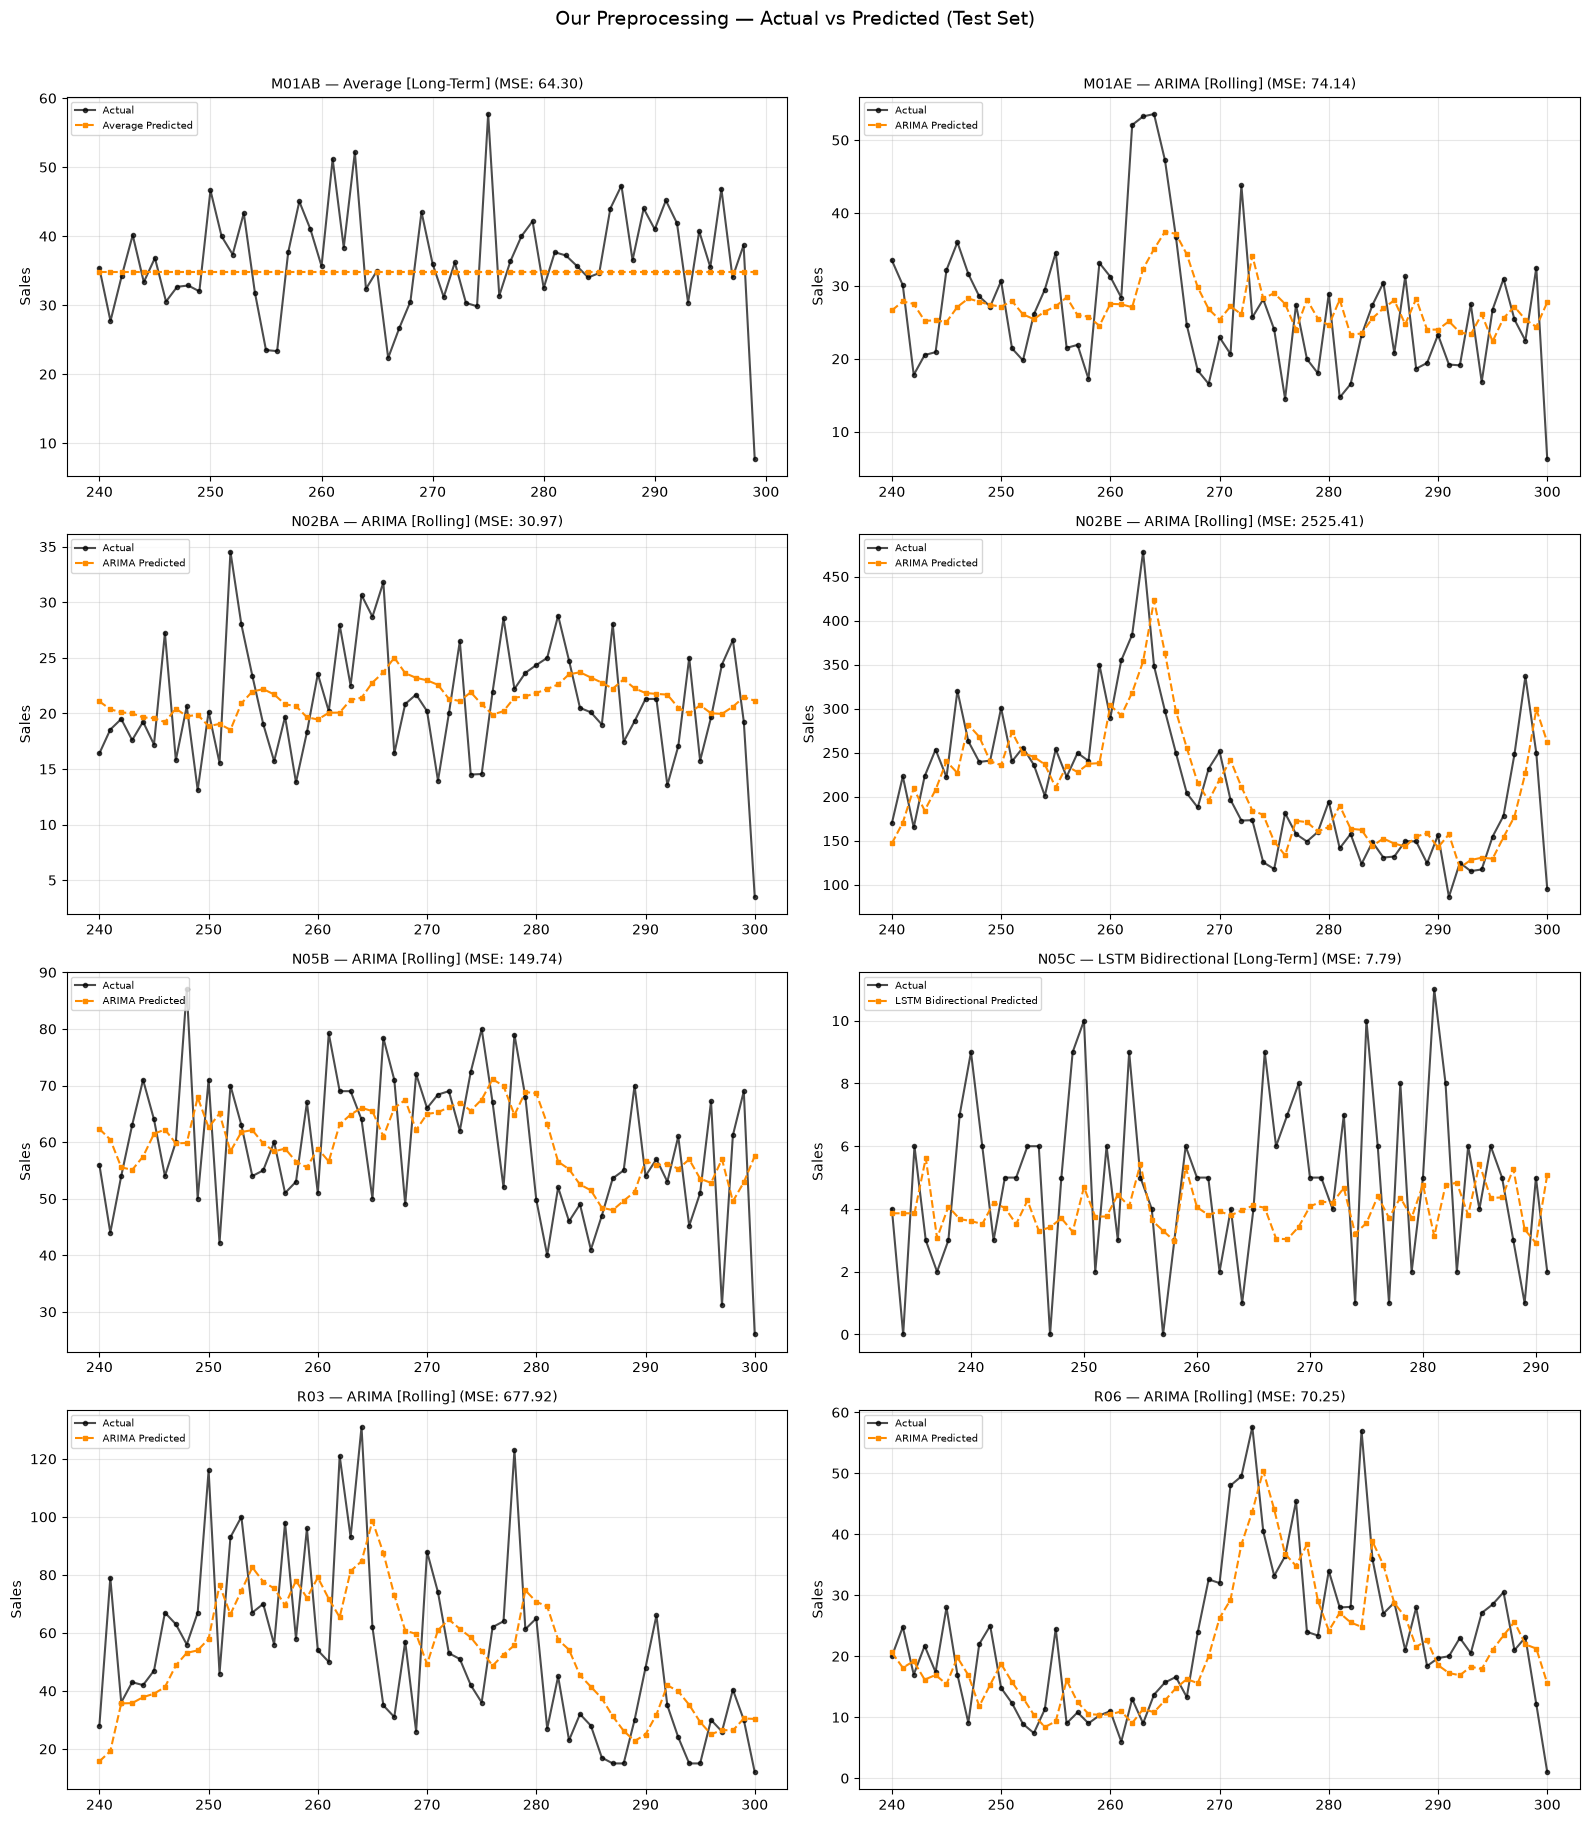

In [53]:
# Actual vs Predicted — Our Preprocessing
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, row in our_best.iterrows():
    cat = row["Category"]
    method = row["Method"]
    item_list = [d for d in transformed_categories if d["Category"] == cat]
    if not item_list:
        continue
    item = item_list[0]
    train_y = item["y_train"]
    test_y = item["y_test"]
    train_size = len(train_y)
    test_mse = row["Test MSE"]

    ax = axes[idx]
    ax.plot(range(train_size, train_size + len(test_y)), test_y, "o-", color="black", linewidth=1.5, markersize=3, label="Actual", alpha=0.7)

    try:
        if method == "Naive":
            test_pred = np.array([train_y[-1]] + list(test_y[:-1]))
        elif method == "Seasonal Naive":
            all_y = np.concatenate([train_y, test_y])
            test_pred = np.array([all_y[train_size + i - SEASONAL_PERIOD] if train_size + i >= SEASONAL_PERIOD else train_y[-1] for i in range(len(test_y))])
        elif method == "Average":
            test_pred = np.full(len(test_y), np.mean(train_y))
        elif method == "ARIMA":
            initial_model = auto_arima(train_y, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore", max_p=5, max_q=5)
            order = tuple(initial_model.order)
            history = list(train_y)
            preds = []
            for actual in test_y:
                m = ARIMA(history, order=order)
                mf = m.fit()
                preds.append(mf.forecast(steps=1)[0])
                history.append(actual)
            test_pred = np.array(preds)
        elif method == "ARIMA Long-Term":
            best_mse_v = np.inf
            best_order_v = (1, 1, 1)
            for p in range(0, 4):
                for d in range(0, 2):
                    for q in range(0, 4):
                        try:
                            m2 = ARIMA(train_y, order=(p, d, q))
                            f2 = m2.fit()
                            p2 = f2.predict(start=0, end=len(train_y)-1)
                            mse_val = mean_squared_error(train_y, p2)
                            if mse_val < best_mse_v:
                                best_mse_v = mse_val
                                best_order_v = (p, d, q)
                        except Exception:
                            continue
            fitted = ARIMA(train_y, order=best_order_v).fit()
            test_pred = fitted.forecast(steps=len(test_y))
        elif method == "Prophet":
            train_df = item["train_df"][["ds", "y"]].copy()
            test_days = len(test_y)
            prophet_model = Prophet(weekly_seasonality="auto", yearly_seasonality="auto")
            prophet_model.fit(train_df)
            future = prophet_model.make_future_dataframe(periods=test_days, freq="W")
            forecast = prophet_model.predict(future)
            test_pred = forecast["yhat"].to_numpy(dtype=float)[-test_days:]
        elif method.startswith("LSTM"):
            X_train = item["X_train"]
            X_test = item["X_test"]
            nf = X_train.shape[1]
            Xt_seq = []
            for i in range(N_STEPS, len(X_train)):
                Xt_seq.append(X_train[i-N_STEPS:i].flatten())
            Xt_seq = np.array(Xt_seq).reshape(-1, N_STEPS, nf)
            yt_seq = train_y[N_STEPS:]
            Xe_seq = []
            for i in range(N_STEPS, len(X_test)):
                Xe_seq.append(X_test[i-N_STEPS:i].flatten())
            Xe_seq = np.array(Xe_seq).reshape(-1, N_STEPS, nf)
            mdl = build_lstm((N_STEPS, nf), "vanilla", LSTM_UNITS)
            mdl.fit(Xt_seq, yt_seq, epochs=100, batch_size=16, validation_split=0.1, verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
            pred_raw = mdl.predict(Xe_seq, verbose=0).flatten()
            test_pred = np.full(len(test_y), np.mean(train_y))
            test_pred[N_STEPS:] = pred_raw
        else:
            test_pred = np.full(len(test_y), np.mean(train_y))
    except Exception:
        test_pred = np.full(len(test_y), np.mean(train_y))

    test_pred = np.maximum(test_pred, 0)
    color = "darkorange"
    ax.plot(range(train_size, train_size + len(test_y)), test_pred, "s--", color=color, linewidth=1.5, markersize=3, label=f"{method} Predicted")
    ax.set_title(f"{cat} \u2014 {method} [{row['Scenario']}] (MSE: {test_mse:.2f})", fontsize=10)
    ax.set_ylabel("Sales")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Our Preprocessing \u2014 Actual vs Predicted (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# Summary

## Experimental Setup

Two preprocessing approaches compared using 6 forecasting models on 8 ATC categories with weekly pharma sales data:

| Aspect | Reference (Paper) | Our Preprocessing |
|--------|-------------------|-------------------|
| Split | Last 52 weeks test | 80/20 (train/test) |
| Features | Raw y | ACF-based lag_n + rolling_mean |
| Scenarios | Rolling + Long-Term | Rolling + Long-Term |
| Tuning | Auto-ARIMA / Grid Search / Default | Same |

## Models

| # | Model | Scenario | Type |
|---|-------|----------|------|
| 1 | Naive | Rolling | Baseline |
| 2 | Seasonal Naive | Rolling | Baseline |
| 3 | Average | Long-Term | Baseline |
| 4 | ARIMA | Rolling | Statistical |
| 5 | ARIMA Long-Term | Long-Term | Statistical |
| 6 | Prophet | Rolling + Long-Term | ML |
| 7 | LSTM Vanilla | Long-Term | Deep Learning |
| 8 | LSTM Stacked | Long-Term | Deep Learning |
| 9 | LSTM Bidirectional | Long-Term | Deep Learning |

## Key Findings

- ARIMA Rolling consistently outperforms baselines for short-term forecasting (per paper Table 1).
- ARIMA Long-Term with grid search provides competitive long-term forecasts.
- LSTM models capture non-linear patterns for long-term forecasting across both preprocessing approaches.
- Prophet provides reliable default-config forecasts with minimal tuning.
- Our preprocessing (ACF lag features) may improve LSTM performance by providing richer input context.
- Baseline methods (Naive, Seasonal Naive, Average) provide lower-bound accuracy benchmarks.

## Limitations

- Weekly data has limited observations (~300 data points), constraining model complexity.
- LSTM training uses fixed hyperparameters without grid search optimization.
- Only MSE used as evaluation metric (MAPE excluded for simplicity).
- Our preprocessing features may benefit from further ablation studies.
